In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

# Import Class
from pathlib import Path

In [2]:
# Set Path to current working directory
cwd = Path.cwd()

# Set ROOT
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

In [3]:
# Create DATA_RAW
DATA_RAW = ROOT / "data" / "raw"

In [4]:
# Create FIGURES
FIGURES = ROOT / "figures"

In [5]:
# Create DATA_PROCESSED
DATA_PROCESSED = ROOT / "data" / "processed"

In [6]:
# Set scope in years of datasets
YEAR_MIN = 2015
YEAR_MAX = 2023

In [7]:
# Verify all paths
print("ROOT:", ROOT)
print("RAW DATA:", DATA_RAW)
print("PROCESSED DATA:", DATA_PROCESSED)
print("FIGURES:", FIGURES)

ROOT: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1
RAW DATA: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/raw
PROCESSED DATA: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/processed
FIGURES: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/figures


In [8]:
# Load first raw file
RAW_DEMOGRAPHIC_ASPECTS_FILE = DATA_RAW / "Demographic-aspects-2023.xlsx"

In [9]:
# Create "if statement" to test for errors
if not RAW_DEMOGRAPHIC_ASPECTS_FILE.exists():
    raise FileNotFoundError

In [10]:
# Load Excel processed to csv for merging
PCT_AGE_15_59_FILE = DATA_PROCESSED / "pct_age_15_59.csv"

In [11]:
# Create "if statement" to test for errors
if not PCT_AGE_15_59_FILE.exists():
    raise FileNotFoundError

In [12]:
# Load DataFrame wide format
df_wide = pd.read_excel(RAW_DEMOGRAPHIC_ASPECTS_FILE, header=1)

In [13]:
# Assign pct_age dataset to a variable
ratio_clean = pd.read_csv(PCT_AGE_15_59_FILE)

In [14]:
# Rename column and melt DataFrame
df_wide = df_wide.rename(columns={"Key Demographic aspects":"Indicator"})

df_long = df_wide.melt(
    id_vars=["Indicator", "Unit"],
    var_name="Year",
    value_name="Value"
)

In [15]:
# Change dtype and create new variables
df_long["Year"] = df_long["Year"].astype(int)

youth_pop = df_long[df_long["Indicator"]=="Pop. 14 years and younger"]
elderly_pop = df_long[df_long["Indicator"]=="Pop. 60 years and older"]

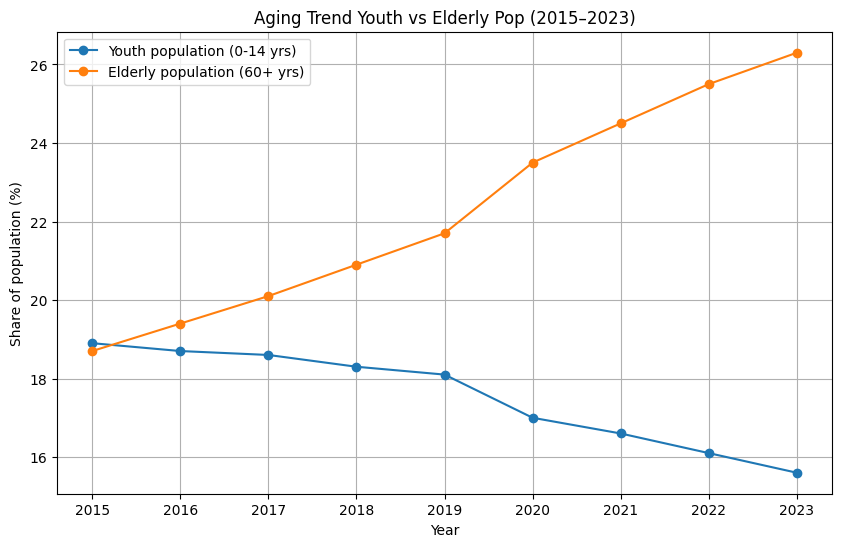

In [16]:
# Create line chart
plt.figure(figsize=(10,6))

plt.plot(youth_pop["Year"], youth_pop["Value"], label="Youth population (0-14 yrs)", marker="o")
plt.plot(elderly_pop["Year"], elderly_pop["Value"], label="Elderly population (60+ yrs)", marker="o")

plt.legend()
plt.title("Aging Trend Youth vs Elderly Pop (2015–2023)")
plt.xlabel("Year")
plt.ylabel("Share of population (%)")

plt.grid(True)

# Save figure
plt.savefig(FIGURES / "aging_trend_youth_elderly.png", dpi=300)

# Show plot